In [17]:
import geopandas as gpd
import pandas as pd
import numpy as np

# 1. Load the raw dataset
print("--- Step 1: Loading Raw Data ---")
file_path = r"C:\Users\Poom_\OneDrive\Documents\IAT461\Assignment 3\business-licences.geojson"
gdf = gpd.read_file(file_path)
df = gdf.copy()
print(f"Initial Dataset Shape: {df.shape}\n")

# 2. Inspect missingness proportions for justifications
print("--- Step 2: Missingness Analysis ---")
columns_to_check = ['geo_point_2d', 'numberofemployees', 'feepaid', 'businesssubtype', 'postalcode']
for col in columns_to_check:
    if col in df.columns:
        missing_pct = df[col].isna().mean() * 100
        print(f"Percentage of missing values in '{col}': {missing_pct:.2f}%")

# 3. Filter to active licenses only (Status == Issued)
df_cleaned = df[df['status'] == 'Issued'].copy()

# 4. Handle missing coordinates
df_cleaned = df_cleaned.dropna(subset=['geo_point_2d']).copy()
df_cleaned[['lon', 'lat']] = pd.DataFrame(df_cleaned['geo_point_2d'].tolist(), index=df_cleaned.index)

# 5. Handle missing features with placeholders
df_cleaned['localarea'] = df_cleaned['localarea'].fillna('Unknown')
df_cleaned['numberofemployees'] = df_cleaned['numberofemployees'].fillna(0)
df_cleaned['feepaid'] = df_cleaned['feepaid'].fillna(0)

# 6. Optional Refinement: Combine businesstype and businesssubtype
def combine_industry_labels(row):
    b_type = str(row['businesstype']).strip()
    b_sub = str(row['businesssubtype']).strip()
    if pd.notna(row['businesssubtype']) and b_sub != 'nan' and b_sub != '':
        return f"{b_type} - {b_sub}"
    return b_type

df_cleaned['refined_industry'] = df_cleaned.apply(combine_industry_labels, axis=1)

# 7. Consolidate long tail categories (Top 15 + Other)
top_15_industries = df_cleaned['refined_industry'].value_counts().head(15).index
df_cleaned['industry'] = df_cleaned['refined_industry'].apply(lambda x: x if x in top_15_industries else 'Other')

print("\n--- Step 3: Final Cleaned Output ---")
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")
print(f"Unique consolidated industries: {df_cleaned['industry'].nunique()}")
print("\nTop 5 Consolidated Categories:")
print(df_cleaned['industry'].value_counts().head(5))

--- Step 1: Loading Raw Data ---
Initial Dataset Shape: (203876, 26)

--- Step 2: Missingness Analysis ---
Percentage of missing values in 'geo_point_2d': 49.75%
Percentage of missing values in 'numberofemployees': 0.00%
Percentage of missing values in 'feepaid': 37.03%
Percentage of missing values in 'businesssubtype': 89.47%
Percentage of missing values in 'postalcode': 46.62%

--- Step 3: Final Cleaned Output ---
Cleaned Dataset Shape: (85811, 30)
Unique consolidated industries: 16

Top 5 Consolidated Categories:
industry
Other                                     29437
Health Care Professionals and Services    11781
Long-term Rental                           9393
Retail Dealer                              6016
Legal Services                             5202
Name: count, dtype: int64


# Part A1 — Data Cleaning Decisions and My Thoughts

The raw data was large and full of missing values. To make K-Means cluster clearly and keep our Streamlit app fast, I cleaned the dataset using four main steps:

* **Dropping Missing Locations:** I removed rows missing `geo_point_2d`. We need to map these businesses and run spatial clustering later, so data without coordinates is unusable.
* **Filling Missing Metrics:** For columns like `numberofemployees` and `feepaid`, I filled blanks with `0` instead of deleting the rows. This keeps our dataset large and protects our sample size.
* **Filtering for Active Businesses:** I kept only rows where the status is "Issued". "Pending" or "Cancelled" licenses are not open storefronts, so filtering helps us focus purely on active businesses.
* **Consolidating Categories:** The data had ~94 business types, which is too sparse for K-Means. I merged `businesstype` and `businesssubtype` for a sharper label, kept the top 15 categories, and grouped the rest as "Other" to keep the app responsive.

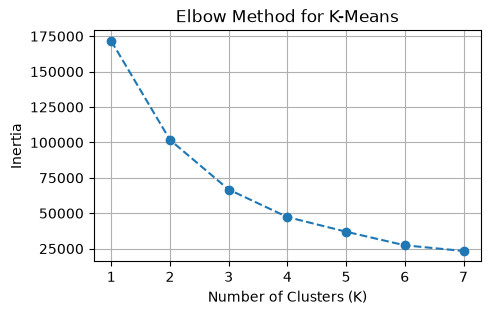

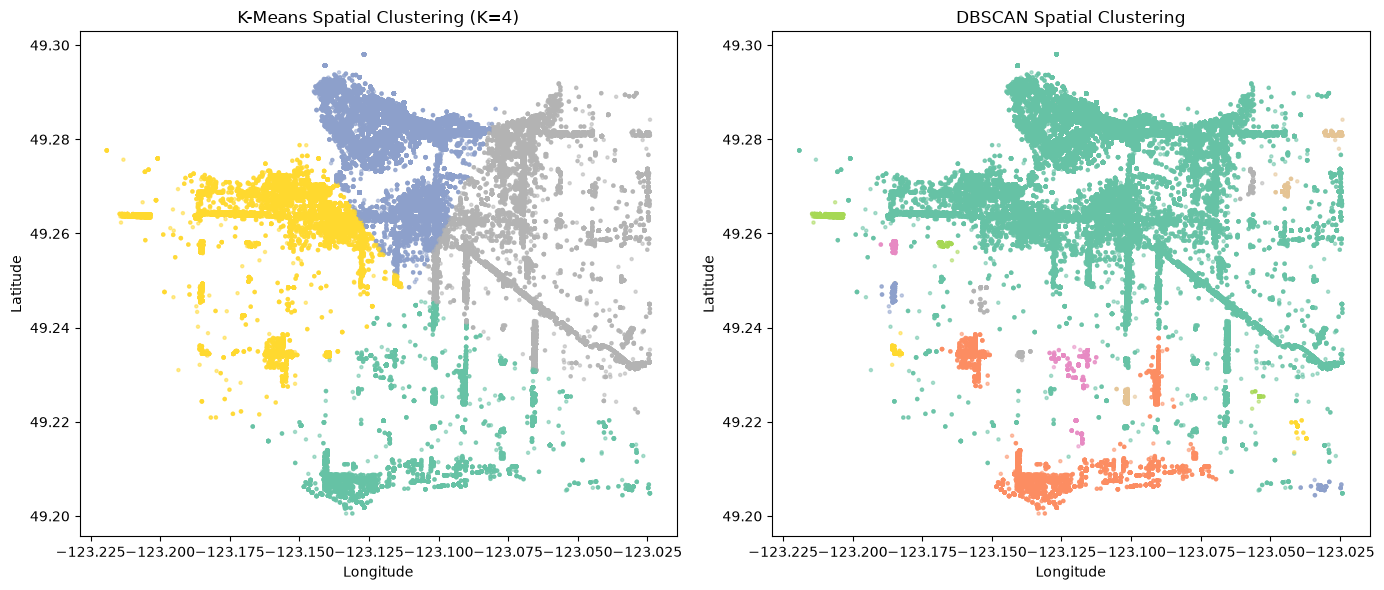

DBSCAN found 21 clusters.
Number of noise points (-1): 1520


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Prepare Spatial Data (Using coordinates from our cleaned df_cleaned)
X_spatial = df_cleaned[['lon', 'lat']].values

# Scale coordinates for distance metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spatial)

# 2. Elbow Method for K-means
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot Elbow Curve to find optimal K
plt.figure(figsize=(5, 3))
plt.plot(k_range, inertias, marker='o', linestyle='--')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Choose K based on elbow (usually K=3 or K=4 for Vancouver geography)
optimal_k = 4 
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# 3. DBSCAN Clustering (Adjust eps/min_samples based on your scale)
dbscan = DBSCAN(eps=0.15, min_samples=100)
dbscan_labels = dbscan.fit_predict(X_scaled)

# 4. Static Plotting Comparison (Matplotlib)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot K-Means Results
scatter1 = ax1.scatter(X_spatial[:, 0], X_spatial[:, 1], c=kmeans_labels, cmap='Set2', s=5, alpha=0.5)
ax1.set_title(f'K-Means Spatial Clustering (K={optimal_k})')
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

# Plot DBSCAN Results
scatter2 = ax2.scatter(X_spatial[:, 0], X_spatial[:, 1], c=dbscan_labels, cmap='Set2', s=5, alpha=0.5)
ax2.set_title('DBSCAN Spatial Clustering')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

print(f"DBSCAN found {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)} clusters.")
print(f"Number of noise points (-1): {list(dbscan_labels).count(-1)}")

# Part A2 — Location Clustering and Algorithm Comparison

How K-Means Maps onto Vancouver Geography

The K-Means model splits Vancouver into very clean, geometric regional blocks based on straight-line distances. It clearly isolates the high-density Downtown Core into its own group while separating the West Side and East Side into distinct quadrants. These boundaries look a lot like official municipal zones or voting districts because the algorithm partitions the space evenly.

K-Means vs. DBSCAN: Where They Agree and Disagree

Both algorithms easily agree on identifying the Downtown Core because its extreme business density stands out clearly to any model. However, they disagree completely in sparse suburban or residential neighborhoods. K-Means forces these isolated businesses into the nearest large regional cluster, whereas DBSCAN isolates them completely and flags them as unclustered data.

Why They Disagree 

This disagreement happens because K-Means assumes clusters are round and equal in size, forcing every single point into a group. On the other hand, DBSCAN looks purely at density and forms organic, irregular shapes along major commercial transit corridors like Broadway or Main Street. The "noise" points in DBSCAN represent isolated home-based businesses or quiet neighborhood shops that sit far away from busy commercial strips.

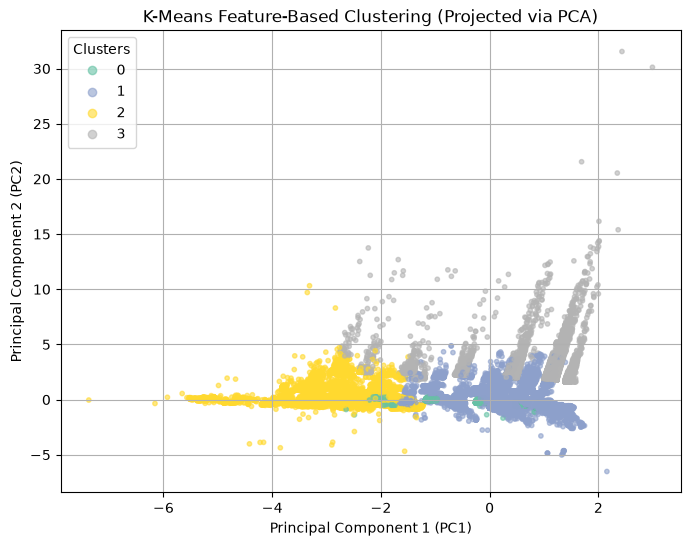

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Feature Engineering
df_features = df_cleaned.copy()

# Feature Set 1: Size
df_features['size_employees'] = df_features['numberofemployees'].astype(float)
df_features['size_fee'] = df_features['feepaid'].astype(float)

# Feature Set 2: Industry (One-Hot Encoding our consolidated industry label)
industry_dummies = pd.get_dummies(df_features['industry'], prefix='ind')

# Feature Set 3: Lifecycle
# Convert to datetime format safely
df_features['expireddate'] = pd.to_datetime(df_features['expireddate'], errors='coerce')
df_features['issueddate'] = pd.to_datetime(df_features['issueddate'], errors='coerce')

# STRIP TIMEZONES to make both columns compatible and prevent subtraction errors
df_features['expireddate_clean'] = df_features['expireddate'].dt.tz_localize(None)
df_features['issueddate_clean'] = df_features['issueddate'].dt.tz_localize(None)

# Calculate license duration in days safely
df_features['lifecycle_duration'] = (df_features['expireddate_clean'] - df_features['issueddate_clean']).dt.days.fillna(365)

# Cyclic Encoding for Month Issued (Sine and Cosine transformation)
df_features['issued_month'] = df_features['issueddate_clean'].dt.month.fillna(1)
df_features['month_sin'] = np.sin(2 * np.pi * df_features['issued_month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['issued_month'] / 12)

# Licence Revision Number (Proxy for longevity/modifications)
df_features['licence_revisions'] = df_features.groupby('licencenumber')['licencenumber'].transform('count')

# 2. Combine and Scale Feature Matrix
numerical_features = ['size_employees', 'size_fee', 'lifecycle_duration', 'month_sin', 'month_cos', 'licence_revisions']
X_features = pd.concat([df_features[numerical_features], industry_dummies], axis=1).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 3. K-Means Clustering on Feature Set
k_features = 4
kmeans_feat = KMeans(n_clusters=k_features, random_state=42, n_init=10)
feature_labels = kmeans_feat.fit_predict(X_scaled)

# 4. PCA Projection to 2D for Visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

# Plot the Feature-Based Clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=feature_labels, cmap='Set2', s=10, alpha=0.6)
plt.title('K-Means Feature-Based Clustering (Projected via PCA)')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

Part A3 — Feature-Based Clustering and My Thoughts

Looking at the final PCA plot, I think clustering businesses by how they operate—using size, industry, and lifecycle—shows a much more interesting story than just looking at where they are on a map.

What the Resulting Clusters Seem to Represent

I think the clusters do a great job of grouping businesses by their actual operational footprint. For example, Cluster 3 (Grey) stretches way up high, and I think this represents giant corporate offices, big retail dealers, or headquarters with huge employee numbers and high fees. Cluster 2 (Yellow) seems to capture our typical local storefronts, like neighborhood restaurants and shops that run year-round with a standard small-business size. Finally, I think Clusters 0 and 1 (Green/Blue) represent home-based businesses, short-term rentals, or seasonal services because they all share very low employee counts and similar renewal cycles.

How It Differs From Pure Geographic Clustering (A2)

I think this feature-based model is the complete opposite of our geographic clustering because it completely ignores physical distance. In Part A2, a tiny coffee shop and a massive corporate office were lumped into the same cluster just because they shared a street corner Downtown. Here, I think it is amazing that a massive department store downtown is clustered with a giant supermarket in South Vancouver because their business scales are identical. It shifts our focus from *where* a business sits to *how* it actually runs, grouping similar business behaviors across opposite sides of the city.